## Histograms of the likelihood distribution of GOES, IFS and ICON

In [1]:
import autoroot

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from src.analysis import split_likelihoods

from notebooks.utils.patch_likelihoods import load_likelihood_dfs, load_all_dataset_likelihoods
from notebooks.utils.plots import IFS_COLOR, ICON_COLOR, GOES_COLOR

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import os
likelihood_dir_64x64 = os.environ.get('RESULTS_DIR_64x64')

datasets = [
    "goes_train", 
    "goes_test",
    "ifs_train",
    "ifs_test",
    "icon_train",
    "icon_test"
]

likelihood_dfs = load_likelihood_dfs(likelihood_dir_64x64, datasets, add_land_ocean=True)
all_dataset_likelihoods = load_all_dataset_likelihoods(likelihood_dir_64x64, datasets, add_land_ocean=True)

### plot histograms

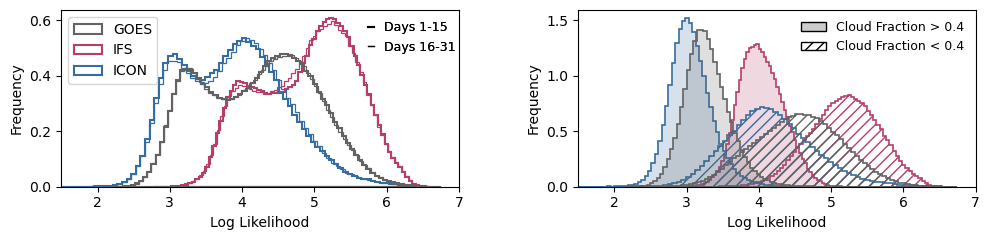

In [3]:
import numpy as np
fig, axs = plt.subplots(1, 2, figsize=(10, 2.5))
ax = axs[0]

train_thickness = 1.5
val_thickness = 0.9

for key, df in likelihood_dfs.items():
    if 'goes' in key: 
        color, zorder = GOES_COLOR, 2
    elif 'ifs' in key: 
        color, zorder = IFS_COLOR, 1
    elif 'icon' in key: 
        color, zorder = ICON_COLOR, 1
    else:
        color, zorder = (0.5, 0.5, 0.5), 1

    label = key.split('_')[0].upper() if 'train' in key else None

    n, bins, patches = ax.hist(
        np.array(df['likelihood']) / (64*64),
        bins=80,
        label=label,
        color=color + (0.0,),
        edgecolor=mcolors.to_hex(color),
        histtype='stepfilled',
        zorder=zorder,
        linewidth=train_thickness if 'train' in key else val_thickness,
        density=True,
    )

# first legend: models
legend1 = ax.legend(loc="upper left")
ax.add_artist(legend1)

# second legend: train/val styles
legend_elements = [
    Line2D([0], [0], color="black", lw=train_thickness, label="Days 1-15"),
    Line2D([0], [0], color="black", lw=val_thickness, label="Days 16-31"),
]
legend2 = ax.legend(handles=legend_elements, loc="upper right",
                    bbox_to_anchor=(1.02, 1),  # move right (x > 1)
                    frameon=False, handlelength=.5, fontsize=9)
ax.add_artist(legend2)

ax.set_xlabel("Log Likelihood")
ax.set_ylabel("Frequency")

ax.set_xlim(1.5, 7)


ax = axs[1]

# cf_cutoff = 0.35
cf_cutoff = 0.4

cf_likelihood_dict = {}
for key, _df in all_dataset_likelihoods.items():
    cf_likelihood_dict[key + '_cloudy'] = _df.loc[_df['cloud_fraction'] > cf_cutoff, 'likelihood']
    cf_likelihood_dict[key + '_not_cloudy'] = _df.loc[_df['cloud_fraction'] < cf_cutoff, 'likelihood']

for key, likelihood_array in cf_likelihood_dict.items():
    if 'goes' in key: 
        color = GOES_COLOR
        zorder = 2
    elif 'ifs' in key: 
        color = IFS_COLOR
        zorder = 1
    elif 'icon' in key: 
        color = ICON_COLOR
        zorder = 1
    if 'not_cloudy' in key: 
        alpha = (0.2,)
    else: 
        alpha = (0.2,)

    n, bins, patches = ax.hist(
        likelihood_array/ (64*64),
        bins=80,
        color=color + (0.0,) if 'not_cloudy' in key else color + (0.2,),
        edgecolor=mcolors.to_hex(color),
        histtype='stepfilled',
        zorder=zorder,
        label=key.split('_')[0].upper() if 'land' in key else None,
        linewidth=1.2,
        density=True,
    )

    # add hatching for ocean 
    if 'not_cloudy' in key:
        for patch in patches:
            patch.set_hatch('///')

ax.set_xlim(1.5, 7)

# second legend: land vs ocean styles
legend_elements = [
    Patch(facecolor=(0,0,0,.2), edgecolor="black", label="Cloud Fraction > 0.4"),
    Patch(facecolor="white", hatch="///", edgecolor="black", label="Cloud Fraction < 0.4"),
]
legend2 = ax.legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=9)

plt.xlabel("Log Likelihood")
plt.ylabel("Frequency")
plt.tight_layout()

# increase space between subplots
plt.subplots_adjust(wspace=0.3)